In [1]:
import torch
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import datasets, surface, plotting

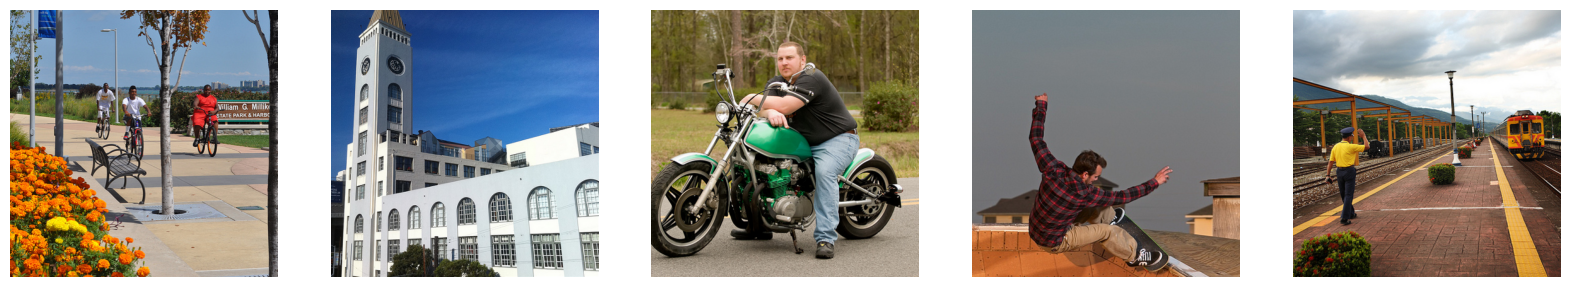

In [2]:
# we proceed by loading all images into a single tensor

# read image ids from filenames
image_ids = [int(filename.split('.')[0]) for filename in os.listdir('../sample_data/images') if filename.endswith('.png')] 
image_ids.sort()  # sort to ensure consistent order

# load images into tensor
images = []
for image_id in image_ids:
    image_path = os.path.join('../sample_data/images', f'{image_id}.png')
    image = Image.open(image_path).convert('RGB')
    image_tensor = torch.tensor(np.array(image)).permute(2, 0, 1)  # Convert to CxHxW
    images.append(image_tensor)

# Stack all images into a single tensor
images_tensor = torch.stack(images)  # Shape: (N, C, H, W

# To test this, visualize first 5 images from the tensor as a single row
plt.figure(figsize=(20, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(images_tensor[i].permute(1, 2, 0).numpy())  # Convert back to HxWxC for display
    plt.axis('off')
plt.show()

In [3]:
# then, we load the raw CLIP token embeddings
token_embeddings = torch.load('../sample_data/sdxl_clip_embeddings.pt')

token_embeddings.shape  # N x T x D where N is the number of images, T is the number of tokens, and D is the embedding dimension

torch.Size([50, 256, 1664])

In [4]:
# The tokens represent 16x16 image patches. We reshape the token embeddings to match the spatial layout of the image patches.
token_embeddings_reshaped = token_embeddings.view(token_embeddings.size(0), 16, 16, token_embeddings.size(2))

token_embeddings_reshaped.shape  # N x 16 x 16 x D

torch.Size([50, 16, 16, 1664])

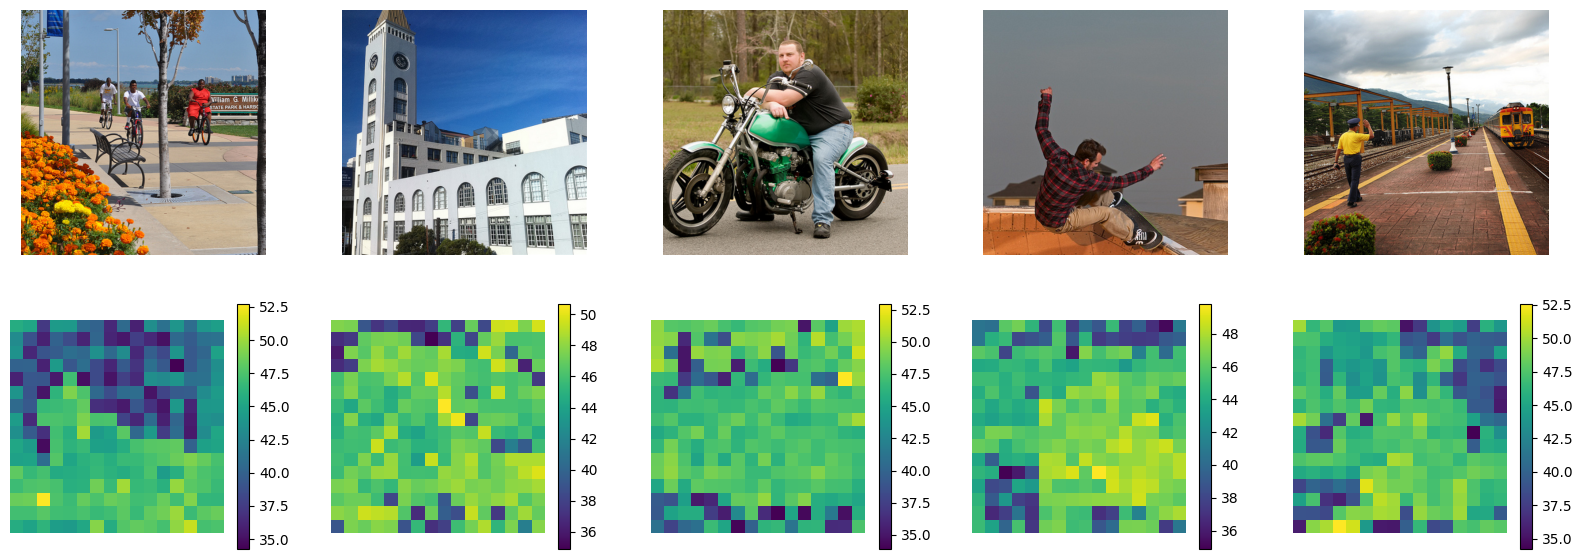

In [5]:
# start our analysis by simply computing the L2 norm of the token embeddings for each image. And visualize the norms as a heatmap for each image.
token_norms = token_embeddings_reshaped.norm(dim=-1)

# Visualize the token norms as heatmaps below their respective images. We will visualize the first 5 images and their corresponding token norm heatmaps.
plt.figure(figsize=(20, 7))
for i in range(5):
    # Display the image
    plt.subplot(2, 5, i + 1)
    plt.imshow(images_tensor[i].permute(1, 2, 0).numpy())
    plt.axis('off')
    
    # Display the token norm heatmap
    plt.subplot(2, 5, i + 6)
    plt.imshow(token_norms[i].numpy(), cmap='viridis', interpolation='nearest')
    plt.colorbar()
    plt.axis('off')

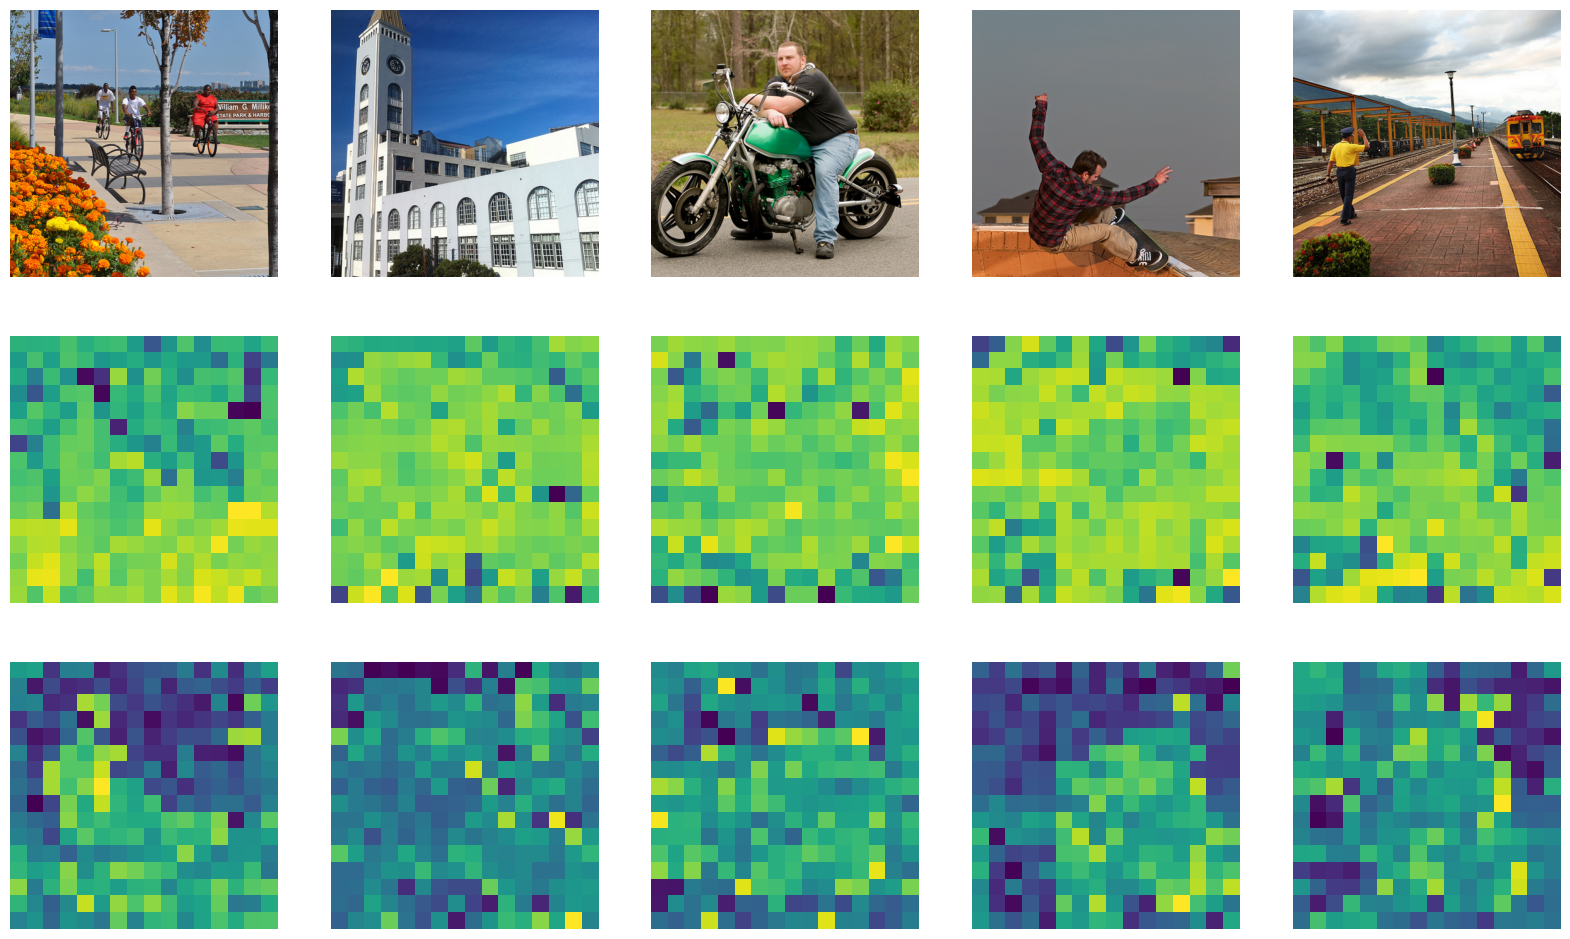

In [6]:
# We do not see a lot of structure, but we also do not see any high-norm outliers.
# We will now compute PCA on the token embeddings to see if we can find any structure in the data.
def pca(X, n_components):
    original_dtype = X.dtype

    if X.dtype in (torch.float16, torch.bfloat16):
        X = X.float()

    mean = X.mean(dim=0)
    X_centered = X - mean

    U, S, Vh = torch.linalg.svd(X_centered, full_matrices=False)

    components = Vh[:n_components]
    X_pca = X_centered @ components.T

    variance = (S ** 2) / (len(X) - 1)
    explained_variance_ratio = variance[:n_components] / variance.sum()

    # Cast outputs back to the original dtype
    return X_pca.to(original_dtype), components.to(original_dtype), explained_variance_ratio.to(original_dtype)

# flatten the token embeddings to (N*T, D) for PCA
token_embeddings_flattened = token_embeddings_reshaped.view(-1, token_embeddings_reshaped.size(-1))

# perform PCA to reduce the dimensionality of the token embeddings to 2D for visualization
token_embeddings_pca, components, explained_variance_ratio = pca(token_embeddings_flattened, n_components=2)

# reshape the PCA results back to (N, 16, 16, 2) for visualization
token_embeddings_pca_reshaped = token_embeddings_pca.view(token_embeddings_reshaped.size(0), 16, 16, 2)

# Analogous to the token norms, we can visualize the PCA results as heatmaps for each image. We will visualize the first 5 images and their corresponding PCA heatmaps.
plt.figure(figsize=(20, 12))
for i in range(5):
    # Display the image
    plt.subplot(3, 5, i + 1)
    plt.imshow(images_tensor[i].permute(1, 2, 0).numpy())
    plt.axis('off')
    
    # Display the PCA heatmap for the first principal component
    plt.subplot(3, 5, i + 6)
    plt.imshow(token_embeddings_pca_reshaped[i, :, :, 0].numpy(), cmap='viridis', interpolation='nearest')
    # plt.colorbar()
    plt.axis('off')

    # Display the PCA heatmap for the second principal component
    plt.subplot(3, 5, i + 11)
    plt.imshow(token_embeddings_pca_reshaped[i, :, :, 1].numpy(), cmap='viridis', interpolation='nearest')
    # plt.colorbar()
    plt.axis('off')
plt.show()